# Normalisation Techniques for Sentence Embeddings

High-dimensional sentence embeddings suffer from a known problem: even unrelated
passages tend to have high cosine similarity. This happens because all embeddings
share a strong "average language direction" — for the Bible, this is the common
theological vocabulary (God, Lord, said, people…) that appears everywhere. Every
embedding points partly in that shared direction, so even dissimilar verses look
similar.

This notebook compares six post-processing techniques for correcting this, applied
to the existing verse embeddings (no re-embedding required). For each technique the
same three views are shown:

1. **Similarity distribution** — does the distribution centre around 0 and spread out?
2. **Genre heatmap** — does genre structure sharpen or disappear?
3. **Query results** — how does the top-10 list for a fixed chapter change?

A final section looks at how local genre centering affects each genre differently.

In [10]:
# ── Configure your query here — change and re-run any cell below ─────────────
QUERY_BOOK    = 'John'
QUERY_CHAPTER = 1
TOP_N         = 10

In [ ]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from sacred_semantics.corpus.bible import load_segments
from sacred_semantics.pipeline.embed import load as load_embeddings
from sacred_semantics.corpus.books import BOOKS

segments = load_segments(Path('../data/processed/bible_kjv.json'))
embeddings = load_embeddings(Path('../embeddings/bible_kjv_intfloat_e5_large_v2.npy'))

print(f'Segments:   {len(segments):,}')
print(f'Embeddings: {embeddings.shape}')

Segments:   31,102
Embeddings: (31102, 1024)


## The six techniques

| Label | What it removes | Notes |
|---|---|---|
| **Baseline** | Nothing | Raw embeddings for reference |
| **AbTT k=1** | Corpus mean direction | Equivalent to mean-centering |
| **AbTT k=3** | Corpus mean + 2 further PCA directions | |
| **AbTT k=5** | Corpus mean + 4 further PCA directions | |
| **Local genre** | Each genre's own mean direction | One mean per genre, not corpus-wide |
| **Whitening** | All variance differences between directions | Most aggressive |

**AbTT** (*All-but-the-Top*, Mu & Viswanath 2018) removes the most dominant
directions from the embedding space. `k` is the total number of directions removed:
k=1 removes only the corpus mean, k=3 removes the mean plus two more principal
components of the centred data, and so on.

**Local genre centering** asks a different question: what makes a verse unusual
*within its own genre*, rather than within the whole Bible? Genres that are
internally homogeneous (NT Gospels, NT History — chapters that follow similar
narrative patterns) should benefit more from this than diverse genres (OT Wisdom,
where each psalm or proverb stands alone).

**Whitening** rescales every direction in the embedding space so the cloud becomes
a perfect sphere — all directions matter equally. This is likely too aggressive for
a space this large, but it is included for completeness.

In [2]:
# ── Normalisation functions ───────────────────────────────────────────────────

def abt_top(embs: np.ndarray, k: int) -> np.ndarray:
    # k=1 subtracts the mean only; k>1 also removes further PCA components
    mean = embs.mean(axis=0)
    centered = (embs - mean).astype(np.float64)
    n_extra = k - 1  # additional PCA components beyond the mean
    if n_extra > 0:
        cov = (centered.T @ centered) / len(centered)
        _, eigenvectors = np.linalg.eigh(cov)           # ascending order
        components = eigenvectors[:, -n_extra:].T        # top PCs as rows
        proj = (centered @ components.T) @ components
        centered = centered - proj
    norms = np.linalg.norm(centered, axis=1, keepdims=True)
    return (centered / np.maximum(norms, 1e-8)).astype(np.float32)


def local_genre_center(embs: np.ndarray, segments: list) -> np.ndarray:
    # Subtract each genre mean, then renormalise
    result = embs.copy().astype(np.float64)
    genre_groups: dict = defaultdict(list)
    for i, s in enumerate(segments):
        genre_groups[(s['testament'], s['genre'])].append(i)
    for indices in genre_groups.values():
        result[indices] -= result[indices].mean(axis=0)
    norms = np.linalg.norm(result, axis=1, keepdims=True)
    return (result / np.maximum(norms, 1e-8)).astype(np.float32)


def whiten(embs: np.ndarray) -> np.ndarray:
    # Subtract mean, then rescale every PCA direction to unit variance
    mean = embs.mean(axis=0)
    centered = (embs - mean).astype(np.float64)
    cov = (centered.T @ centered) / len(centered)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    scaled = centered @ eigenvectors / np.sqrt(np.maximum(eigenvalues, 1e-10))
    norms = np.linalg.norm(scaled, axis=1, keepdims=True)
    return (scaled / np.maximum(norms, 1e-8)).astype(np.float32)


# ── Chapter aggregation ───────────────────────────────────────────────────────

def build_chapter_keys(segments, BOOKS):
    groups: dict = defaultdict(list)
    for i, s in enumerate(segments):
        groups[(s['book'], s['chapter'])].append(i)
    keys = [
        (book.name, ch)
        for book in BOOKS
        for ch in sorted({s['chapter'] for s in segments if s['book'] == book.name})
    ]
    return groups, keys


def to_chapter_sim(verse_embs, chapter_groups, chapter_keys):
    raw = np.stack([verse_embs[chapter_groups[k]].mean(axis=0) for k in chapter_keys])
    norms = np.linalg.norm(raw, axis=1, keepdims=True)
    ce = (raw / np.maximum(norms, 1e-8)).astype(np.float32)
    return ce, (ce @ ce.T)

## Apply all techniques

This cell normalises the verse embeddings six ways, then aggregates to the chapter
level and builds a chapter similarity matrix for each. The PCA step (AbTT and
whitening) typically takes 10–30 seconds depending on hardware.

In [3]:
chapter_groups, chapter_keys = build_chapter_keys(segments, BOOKS)

TECHNIQUES = {
    'Baseline':    embeddings,
    'AbTT k=1':   abt_top(embeddings, k=1),
    'AbTT k=3':   abt_top(embeddings, k=3),
    'AbTT k=5':   abt_top(embeddings, k=5),
    'Local genre': local_genre_center(embeddings, segments),
    'Whitening':   whiten(embeddings),
}

chap_embs, chap_sims = {}, {}
for name, ve in TECHNIQUES.items():
    ce, sim = to_chapter_sim(ve, chapter_groups, chapter_keys)
    chap_embs[name] = ce
    chap_sims[name] = sim
    print(f'{name:<14}  done')

print('\nAll techniques ready.')

Baseline        done
AbTT k=1        done
AbTT k=3        done
AbTT k=5        done
Local genre     done
Whitening       done

All techniques ready.


## 1. Similarity distributions

200,000 random chapter pairs are sampled from each technique's similarity matrix
and plotted as a histogram. The red dashed line marks the mean similarity.

A good distribution for discriminative analysis:
- Mean close to **0** (not 0.7 or 0.8)
- Wide spread — genuinely similar pairs should stand out clearly from the crowd
- Ideally roughly symmetric

The baseline is expected to be right-skewed with a high mean — that is the
concentration-of-measure effect we are trying to correct.

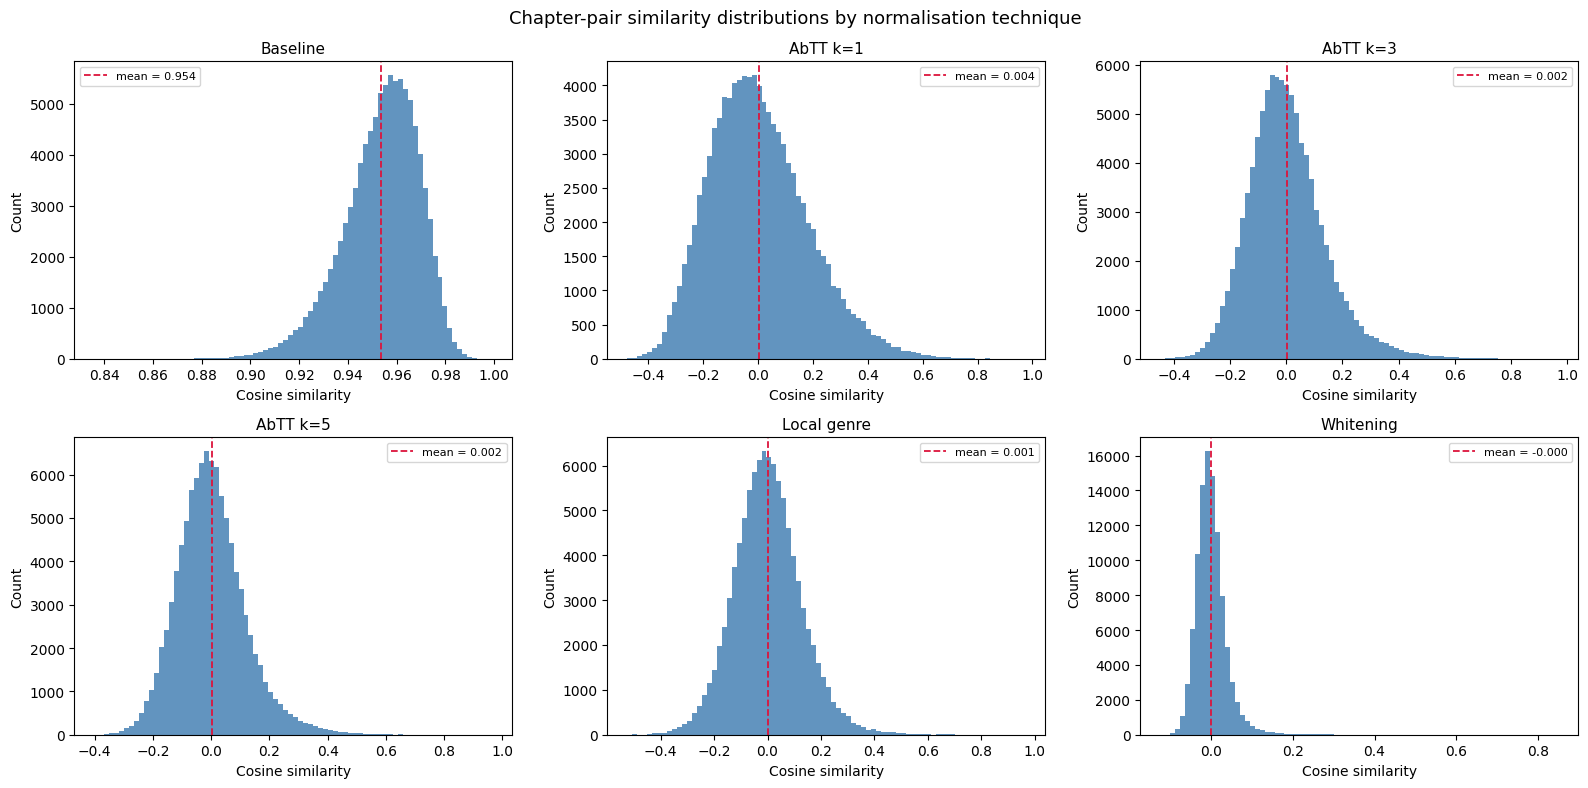

In [4]:
rng = np.random.default_rng(42)
n_ch = len(chapter_keys)
idx_i = rng.integers(0, n_ch, 200_000)
idx_j = rng.integers(0, n_ch, 200_000)
pair_mask = idx_i < idx_j

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, sim) in zip(axes, chap_sims.items()):
    sample = sim[idx_i[pair_mask], idx_j[pair_mask]]
    ax.hist(sample, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(sample.mean(), color='crimson', linestyle='--', linewidth=1.3,
               label=f'mean = {sample.mean():.3f}')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Cosine similarity')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Chapter-pair similarity distributions by normalisation technique', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Genre heatmaps

The same 10-genre grid from notebooks 02 and 03, shown for all six techniques.
Each heatmap is colour-scaled independently so the contrast is visible regardless
of the overall shift in similarity values.

Look for whether the diagonal (a genre compared to itself) stays warm while
off-diagonal cells cool — that would mean genre structure is sharpening. If both
warm and cool at the same rate, the technique is not changing the relative structure.

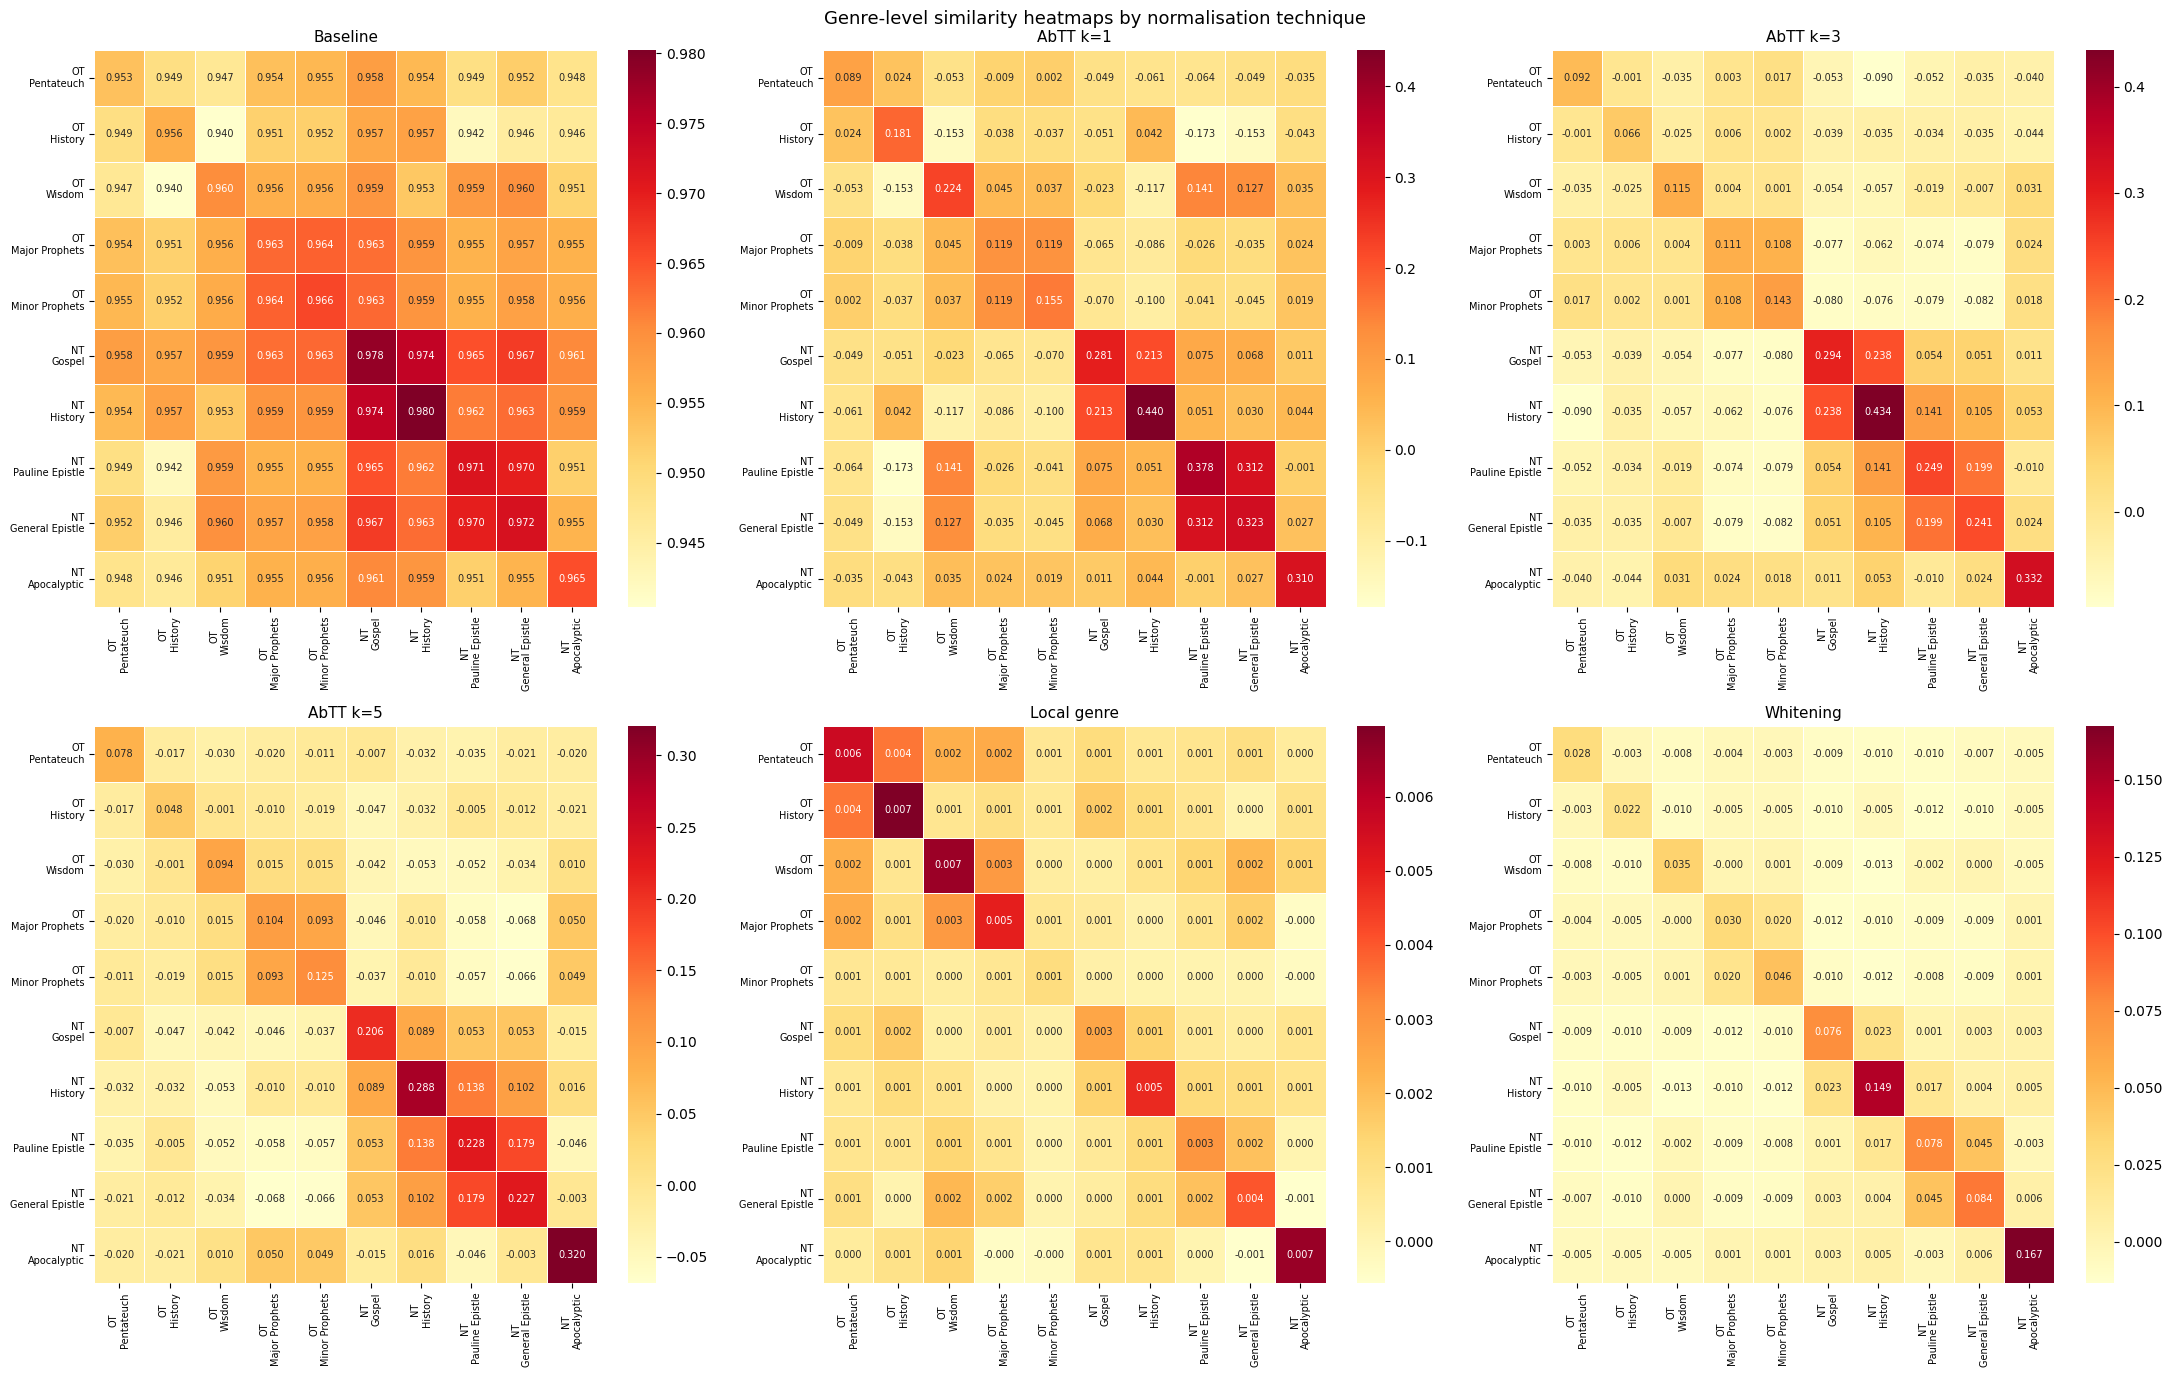

In [5]:
GENRE_ORDER = [
    ('OT', 'Pentateuch'), ('OT', 'History'), ('OT', 'Wisdom'),
    ('OT', 'Major Prophets'), ('OT', 'Minor Prophets'),
    ('NT', 'Gospel'), ('NT', 'History'), ('NT', 'Pauline Epistle'),
    ('NT', 'General Epistle'), ('NT', 'Apocalyptic'),
]
key_to_genre = {(s['book'], s['chapter']): (s['testament'], s['genre']) for s in segments}
genre_ch_idx = {
    g: [i for i, k in enumerate(chapter_keys) if key_to_genre[k] == g]
    for g in GENRE_ORDER
}
genre_labels = [f'{t}\n{g}' for t, g in GENRE_ORDER]


def genre_matrix(sim):
    n = len(GENRE_ORDER)
    m = np.zeros((n, n))
    for i, gi in enumerate(GENRE_ORDER):
        for j, gj in enumerate(GENRE_ORDER):
            m[i, j] = sim[np.ix_(genre_ch_idx[gi], genre_ch_idx[gj])].mean()
    return m


fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

for ax, (name, sim) in zip(axes, chap_sims.items()):
    m = genre_matrix(sim)
    sns.heatmap(m, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=genre_labels, yticklabels=genre_labels,
                ax=ax, vmin=m.min(), vmax=m.max(),
                linewidths=0.4, linecolor='white', annot_kws={'size': 7})
    ax.set_title(name, fontsize=11)
    ax.tick_params(labelsize=7)

fig.suptitle('Genre-level similarity heatmaps by normalisation technique', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Query: most similar chapters

The most concrete comparison: for the chapter set at the top of the notebook
(`QUERY_BOOK`, `QUERY_CHAPTER`), the top results are shown for each technique.

Chapters that appear across multiple techniques are likely genuine semantic
parallels. Chapters that appear only under one technique reflect what that method
is uniquely emphasising (or over-emphasising).

In [11]:
book_names_list = [b.name for b in BOOKS]


def run_query(sim):
    lower = QUERY_BOOK.lower()
    matched = next((b for b in book_names_list if b.lower() == lower), None)
    if matched is None:
        matched = next((b for b in book_names_list if lower in b.lower()), None)
    if matched is None:
        print(f'  Book not found: {QUERY_BOOK}')
        return
    key = (matched, QUERY_CHAPTER)
    if key not in chapter_groups:
        print(f'  {matched} has no chapter {QUERY_CHAPTER}')
        return
    q_idx = chapter_keys.index(key)
    scores = sim[q_idx].copy()
    scores[q_idx] = -1
    ranked = np.argsort(scores)[::-1][:TOP_N]
    print(f'  {"Rank":<4} {"Chapter":<30} {"Score":>8}')
    print(f'  {"-"*4} {"-"*30} {"-"*8}')
    for rank, j in enumerate(ranked, 1):
        bj, chj = chapter_keys[j]
        ref = f'{bj} {chj}'
        print(f'  {rank:<4} {ref:<30} {scores[j]:>8.4f}')


for name, sim in chap_sims.items():
    print(f'\n── {name} ──────────────────────────────')
    run_query(sim)


── Baseline ──────────────────────────────
  Rank Chapter                           Score
  ---- ------------------------------ --------
  1    John 12                          0.9895
  2    John 3                           0.9880
  3    John 6                           0.9876
  4    Luke 7                           0.9872
  5    John 4                           0.9871
  6    Luke 9                           0.9868
  7    John 5                           0.9862
  8    John 7                           0.9860
  9    Mark 1                           0.9858
  10   Mark 9                           0.9858

── AbTT k=1 ──────────────────────────────
  Rank Chapter                           Score
  ---- ------------------------------ --------
  1    John 12                          0.6318
  2    John 9                           0.6228
  3    John 3                           0.6218
  4    John 6                           0.5908
  5    John 4                           0.5866
  6    John 18     

## 4. Local centering: genre coherence analysis

Local genre centering subtracts what is *common within a genre* before comparing.
But genres differ in how internally consistent they are, and that is what makes
this technique interesting.

This section measures **intra-genre self-similarity** — the average cosine
similarity between all chapter pairs within the same genre — before (baseline) and
after local genre centering. A large drop means the genre had a strong shared
direction that centering removed. A small drop means the genre was already diverse
and the subtracted mean was weak.

Expected pattern:
- **NT Gospel / NT History** — narratively formulaic, should show the largest drops
- **OT Wisdom** — varied (Psalms alone spans lament, praise, wisdom, royal poetry),
  should show a smaller drop because there was no single dominant direction to remove
- **OT Major / Minor Prophets** — somewhere in between

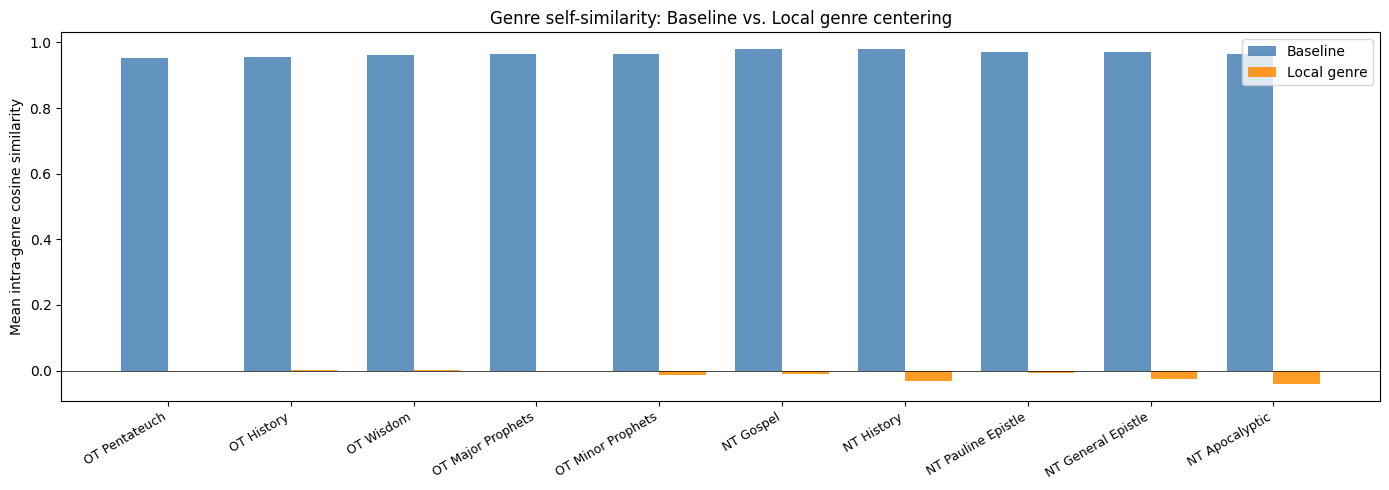

Genre                        Baseline      Local       Drop
----------------------------------------------------------
OT Pentateuch                  0.9532     0.0003     0.9529
OT History                     0.9558     0.0029     0.9528
OT Wisdom                      0.9601     0.0024     0.9577
OT Major Prophets              0.9630    -0.0005     0.9634
OT Minor Prophets              0.9654    -0.0140     0.9794
NT Gospel                      0.9783    -0.0088     0.9870
NT History                     0.9795    -0.0321     1.0115
NT Pauline Epistle             0.9710    -0.0086     0.9797
NT General Epistle             0.9710    -0.0261     0.9972
NT Apocalyptic                 0.9637    -0.0407     1.0045


In [7]:
genre_short = [f'{t} {g}' for t, g in GENRE_ORDER]

baseline_self, local_self = [], []
for g in GENRE_ORDER:
    idx = genre_ch_idx[g]
    if len(idx) < 2:
        baseline_self.append(np.nan)
        local_self.append(np.nan)
        continue
    tri = np.triu(np.ones(len(idx), dtype=bool), k=1)
    baseline_self.append(chap_sims['Baseline'][np.ix_(idx, idx)][tri].mean())
    local_self.append(chap_sims['Local genre'][np.ix_(idx, idx)][tri].mean())

x = np.arange(len(GENRE_ORDER))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, baseline_self, w, label='Baseline',    color='steelblue',  alpha=0.85)
ax.bar(x + w/2, local_self,    w, label='Local genre', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(genre_short, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean intra-genre cosine similarity')
ax.set_title('Genre self-similarity: Baseline vs. Local genre centering')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

print(f'{"Genre":<26} {"Baseline":>10} {"Local":>10} {"Drop":>10}')
print('-' * 58)
for label, b, l in zip(genre_short, baseline_self, local_self):
    drop = b - l
    print(f'{label:<26} {b:>10.4f} {l:>10.4f} {drop:>10.4f}')